# Autoencoder Bottleneck Experiment (MNIST)

This notebook implements a **symmetric autoencoder** to study how the **latent bottleneck size affects reconstruction quality**.

Architecture:

Encoder:
784 → 128 → 64 → N

Decoder:
N → 64 → 128 → 784

Experiments:
- Bottleneck N = 2
- Bottleneck N = 32

Goal: Observe how compression affects reconstruction quality.

## Import Required Libraries

In [1]:
# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
# Dataset utilities
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt

# For reproducibility
torch.manual_seed(42)

In [2]:
from torch.utils.data import Dataset

class MNISTDataset(Dataset):

    def __init__(self, csv_file):

        data = pd.read_csv(csv_file)

        # First column is label
        self.labels = torch.tensor(data.iloc[:,0].values, dtype=torch.long)

        # Remaining columns are pixels
        self.images = torch.tensor(data.iloc[:,1:].values, dtype=torch.float32)

        # Normalize pixels
        self.images = self.images / 255.0


    def __len__(self):
        return len(self.labels)


    def __getitem__(self, idx):

        image = self.images[idx]
        label = self.labels[idx]

        return image, label

## Load MNIST Dataset

In [3]:
#change the path here
train_dataset = MNISTDataset("C:\\Users\\Vansh\\Desktop\\DeepLearning-Project\\Assignment3\\Problem1\\Problem1.1\\MNIST\\mnist_train.csv")
test_dataset = MNISTDataset("C:\\Users\\Vansh\\Desktop\\DeepLearning-Project\\Assignment3\\Problem1\\Problem1.1\\MNIST\\mnist_test.csv")
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)

## Define the Symmetric Autoencoder

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck_size):
        super(Autoencoder, self).__init__()

        # Encoder compresses the input image
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, bottleneck_size)
        )

        # Decoder reconstructs the image
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Flatten image from 28x28 to 784
        x = x.view(-1, 784)

        # Encode
        latent = self.encoder(x)

        # Decode
        reconstructed = self.decoder(latent)

        return reconstructed

## Training Function

In [5]:
def train_autoencoder(bottleneck_size, epochs=10):

    model = Autoencoder(bottleneck_size)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, images)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

    return model

## Train Model with Bottleneck N = 2

In [6]:
model_n2 = train_autoencoder(2)

Epoch 1/10, Loss: 29.8751
Epoch 2/10, Loss: 22.4433
Epoch 3/10, Loss: 21.2039
Epoch 4/10, Loss: 20.5129
Epoch 5/10, Loss: 20.0856
Epoch 6/10, Loss: 19.7592
Epoch 7/10, Loss: 19.5335
Epoch 8/10, Loss: 19.2920
Epoch 9/10, Loss: 19.0796
Epoch 10/10, Loss: 18.9226


## Train Model with Bottleneck N = 32

In [7]:
model_n32 = train_autoencoder(32)

Epoch 1/10, Loss: 27.4531
Epoch 2/10, Loss: 14.5617
Epoch 3/10, Loss: 11.5781
Epoch 4/10, Loss: 9.8515
Epoch 5/10, Loss: 8.8736
Epoch 6/10, Loss: 8.1648
Epoch 7/10, Loss: 7.5496
Epoch 8/10, Loss: 7.0976
Epoch 9/10, Loss: 6.7081
Epoch 10/10, Loss: 6.3408


## Visualization of the Bottlenecks

In [8]:
# Function to extract latent representations from the encoder

def get_latent_representations(model, dataloader):

    latents = []
    labels = []

    with torch.no_grad():

        for images, label in dataloader:

            # Pass images through encoder
            latent = model.encoder(images)

            latents.append(latent)
            labels.append(label)

    latents = torch.cat(latents).numpy()
    labels = torch.cat(labels).numpy()

    return latents, labels

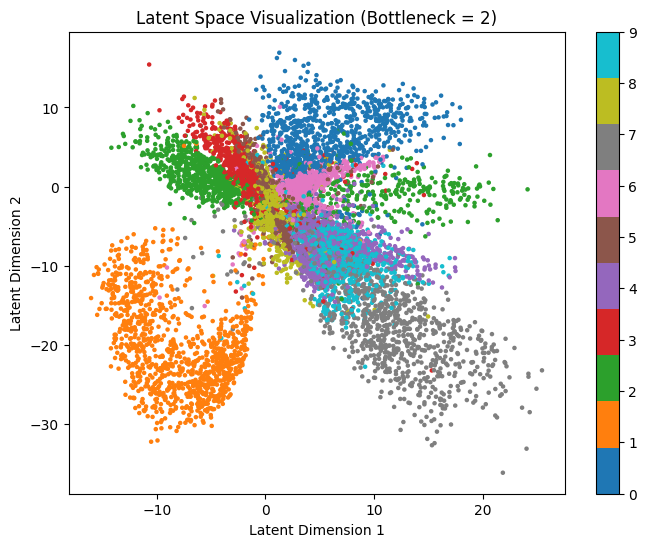

In [9]:
import matplotlib.pyplot as plt

latents_2, labels_2 = get_latent_representations(model_n2, test_loader)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latents_2[:,0],
    latents_2[:,1],
    c=labels_2,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("Latent Space Visualization (Bottleneck = 2)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.savefig("plots/bottleneck_2_latent.png")

plt.show()

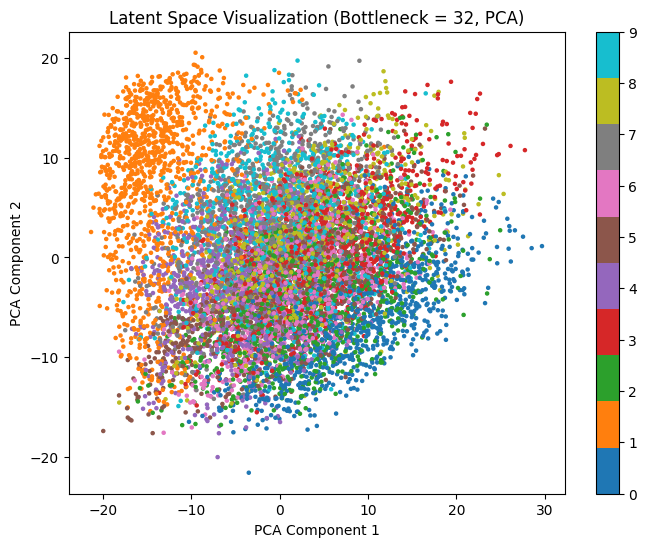

In [10]:
from sklearn.decomposition import PCA

latents_32, labels_32 = get_latent_representations(model_n32, test_loader)

# Reduce 32D → 2D
pca = PCA(n_components=2)
latents_32_pca = pca.fit_transform(latents_32)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latents_32_pca[:,0],
    latents_32_pca[:,1],
    c=labels_32,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("Latent Space Visualization (Bottleneck = 32, PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.savefig("plots/bottleneck_32_latent.png")

plt.show()

## Visualization Function

In [11]:
def show_reconstruction(model):

    images, _ = next(iter(test_loader))

    images_flat = images.view(-1, 784)

    with torch.no_grad():
        reconstructed = model(images_flat)

    reconstructed = reconstructed.view(-1,28,28)

    fig, axes = plt.subplots(2, 10, figsize=(12,4))

    for i in range(10):

        # Original images
        axes[0, i].imshow(images[i].view(28,28), cmap='gray')
        axes[0, i].axis('off')

        # Reconstructed images
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')

    axes[0,0].set_title("Original")
    axes[1,0].set_title("Reconstructed")

    plt.show()

## Reconstruction Results (N = 2)

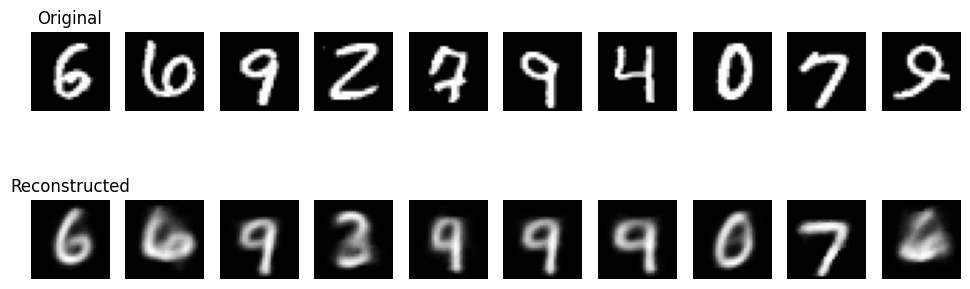

In [12]:
show_reconstruction(model_n2)

## Reconstruction Results (N = 32)

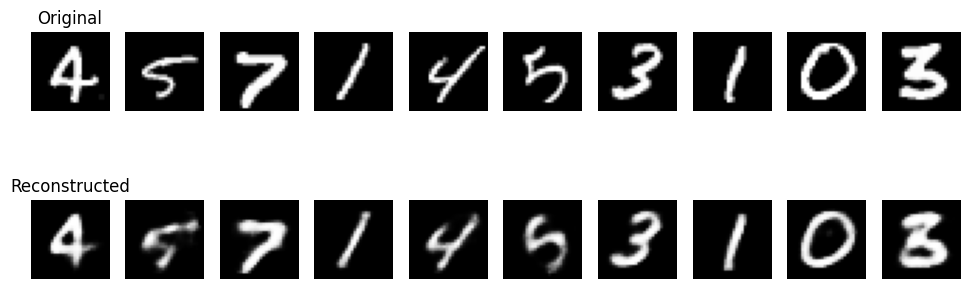

In [13]:
show_reconstruction(model_n32)

## Observations

**N = 2:**
- Images are blurry
- Some digit shapes are lost
- Network compresses image into only 2 values

**N = 32:**
- Reconstructions are much clearer
- Digit structures preserved
- More latent capacity means less information loss

This demonstrates the **compression tradeoff in latent spaces**.